# 04 - Projecting the covariance

Notebook 03 left us with a measured fact: rigid motion keeps a Gaussian
Gaussian, the perspective divide does not. Rendering by sampling is too
expensive, so we take the other road: replace the divide, near each splat's
mean, with the affine map that best matches it there. The error lives in the
tails, where the splat has little mass anyway. This is the EWA splatting idea
(Zwicker et al., 2001) that 3DGS inherits.

## The one rule affine maps obey

For $y = A x + b$ applied to samples with covariance $\Sigma$:

$$\mathrm{Cov}[y] = \mathbb{E}\!\left[(A(x - \mu))(A(x - \mu))^{T}\right]
= A \Sigma A^{T}$$

Three lines of expectation algebra, and the only covariance rule the whole
renderer needs.

## Stage 1, exact: world to camera

$x_\text{cam} = W (x - \text{eye})$ with $W = $ `cam.R`. Affine, so

$$\Sigma_\text{cam} = W \Sigma W^{T}$$

## Stage 2, approximate: the divide

$$\phi(p) = \left(f_x \frac{p_x}{p_z} + c_x,\;
f_y \frac{p_y}{p_z} + c_y\right)$$

Taylor at the camera-space mean $(x, y, z)$ and keep the linear term. The
Jacobian, row by row (differentiate $f_x p_x / p_z$ by each coordinate):

$$J = \begin{bmatrix}
f_x/z & 0 & -f_x x / z^2 \\
0 & f_y/z & -f_y y / z^2
\end{bmatrix}$$

Composing both stages:

$$\Sigma_{2d} = J W \Sigma W^{T} J^{T} \quad (2 \times 2)$$

## Where the depth went

$J$ is 2x3. The affine image of the 3D Gaussian is a 3D Gaussian in
$(u, v, \text{depth})$; the screen only wants $(u, v)$. For a Gaussian, the
marginal
over a subset of coordinates is just the covariance with the other rows and
columns deleted, and the 2x3 shape performs that deletion in one multiply.
So this line integrates the splat along the viewing direction. That is the
"volume rendering" in the papers, collapsed into a matrix shape.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

def quat_to_R(q):
    w, x, y, z = np.asarray(q, float) / np.linalg.norm(q)
    return np.array([
        [1 - 2 * (y * y + z * z), 2 * (x * y - w * z),     2 * (x * z + w * y)],
        [2 * (x * y + w * z),     1 - 2 * (x * x + z * z), 2 * (y * z - w * x)],
        [2 * (x * z - w * y),     2 * (y * z + w * x),     1 - 2 * (x * x + y * y)],
    ])

def build_cov3d(scale, R):
    M = R @ np.diag(np.asarray(scale, float))
    return M @ M.T

def look_at(eye, target, up=(0, -1, 0)):
    eye, target, up = (np.asarray(a, float) for a in (eye, target, up))
    f = target - eye; f = f / np.linalg.norm(f)
    r = np.cross(f, up); r = r / np.linalg.norm(r)
    d = np.cross(f, r)
    return np.stack([r, d, f])

@dataclass
class Camera:
    R: np.ndarray
    eye: np.ndarray
    fx: float; fy: float; cx: float; cy: float
    H: int; W: int

    @classmethod
    def looking_at(cls, eye, target, fx, fy, H, W, up=(0, -1, 0)):
        return cls(look_at(eye, target, up), np.asarray(eye, float),
                   fx, fy, W / 2, H / 2, H, W)

    def world_to_cam(self, P):
        return (np.asarray(P, float) - self.eye) @ self.R.T

    def project(self, Pc):
        z = Pc[..., 2]
        u = self.fx * Pc[..., 0] / z + self.cx
        v = self.fy * Pc[..., 1] / z + self.cy
        return u, v, z

def project_cov3d(cov3d, mean_cam, cam):
    x, y, z = mean_cam
    J = np.array([
        [cam.fx / z, 0.0,        -cam.fx * x / z ** 2],
        [0.0,        cam.fy / z, -cam.fy * y / z ** 2],
    ])
    T = J @ cam.R
    return T @ cov3d @ T.T

cam = Camera.looking_at(eye=[0, 0, -4], target=[0, 0, 0],
                        fx=600, fy=600, H=512, W=512)

## Check the Jacobian before trusting it

Analytic derivatives earn a finite-difference test. Central differences at
the mean, column by column:

In [2]:
def phi(p):
    return np.array([cam.fx * p[0] / p[2] + cam.cx,
                     cam.fy * p[1] / p[2] + cam.cy])

mc = np.array([0.3, -0.2, 2.0])
x, y, z = mc
J_analytic = np.array([
    [cam.fx / z, 0.0,        -cam.fx * x / z ** 2],
    [0.0,        cam.fy / z, -cam.fy * y / z ** 2],
])
eps = 1e-5
J_num = np.stack([(phi(mc + eps * e) - phi(mc - eps * e)) / (2 * eps)
                  for e in np.eye(3)], axis=1)
assert np.allclose(J_num, J_analytic, rtol=1e-4, atol=1e-4)
print("Jacobian matches finite differences")

Jacobian matches finite differences


## The contract, tested against ground truth

Notebook 03's Monte Carlo clouds are the ground truth. Overlay the analytic
1, 2, 3 sigma ellipses of `Sigma_2d` on the same two cases.

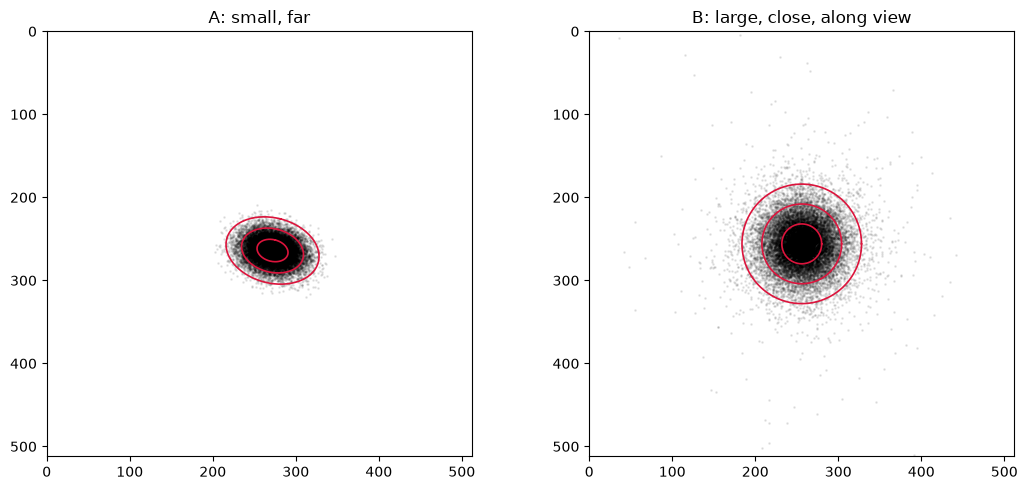

In [3]:
def sample_gaussian3d(mu, R, scale, n, rng):
    zn = rng.standard_normal((n, 3))
    return np.asarray(mu, float) + (zn * np.asarray(scale, float)) @ R.T

def ellipse_points(mu2, S2, k, n=200):
    lam, V = np.linalg.eigh(S2)
    t = np.linspace(0, 2 * np.pi, n)
    circ = np.stack([np.cos(t), np.sin(t)])
    return (V @ (np.sqrt(lam)[:, None] * circ)) * k + np.asarray(mu2)[:, None]

rng = np.random.default_rng(1)
cases = [
    ("A: small, far",
     [0.4, 0.2, 11.0], [0.5, 0.3, 0.4], quat_to_R([0.9, 0.2, 0.3, 0.1])),
    ("B: large, close, along view",
     [0.0, 0.0, -2.0], [0.08, 0.08, 0.55], np.eye(3)),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (name, mu, s, R) in zip(axes, cases):
    X = sample_gaussian3d(mu, R, s, 20_000, rng)
    Xc = cam.world_to_cam(X)
    keep = Xc[:, 2] > 0.05
    u, v, _ = cam.project(Xc[keep])
    ax.scatter(u, v, s=1, alpha=0.08, c="k")

    mc = cam.world_to_cam(np.asarray(mu))
    u0, v0, _ = cam.project(mc)
    S2 = project_cov3d(build_cov3d(s, R), mc, cam)
    for k in (1, 2, 3):
        e = ellipse_points((u0, v0), S2, k)
        ax.plot(e[0], e[1], c="crimson", lw=1.2)
    ax.set_xlim(0, 512); ax.set_ylim(512, 0)
    ax.set_aspect("equal"); ax.set_title(name)
plt.tight_layout()
plt.show()

Case A: the ellipses sit on the cloud. The linearization is the truth for
small or distant splats.

Case B: the cloud funnels toward the camera and the ellipse cannot follow;
a linear map only produces ellipses. This is the approximation's contract:
error grows with splat size relative to its depth. 3DGS accepts the contract
because training, given enough splats, prefers many small ones over one huge
one, and small splats live where the approximation is good.

Footnote for later: the official CUDA kernel also clamps `x/z, y/z` to
`1.3 tan(fov/2)` before building `J`, so means far outside the frustum
cannot produce absurd Jacobians. We will meet it again in phase D.

## Screen-space steps, unchanged from notebook 02

`Sigma_2d` is a notebook-02 covariance, so everything from there applies
as-is: add the `0.3 I` dilation, invert to a conic, bound with the 3-sigma
radius. And notebook 01's near cull (`z <= z_near` -> skip) now protects the
Jacobian too, whose entries carry `1/z` and `1/z^2`.

## One splat, moving camera

The payoff of `J W Sigma W^T J^T` in one picture: a disc-shaped splat
(scales `0.5, 0.5, 0.02`) viewed from an orbiting camera. Nothing about the
splat changes; the projected ellipse forehortens on its own.

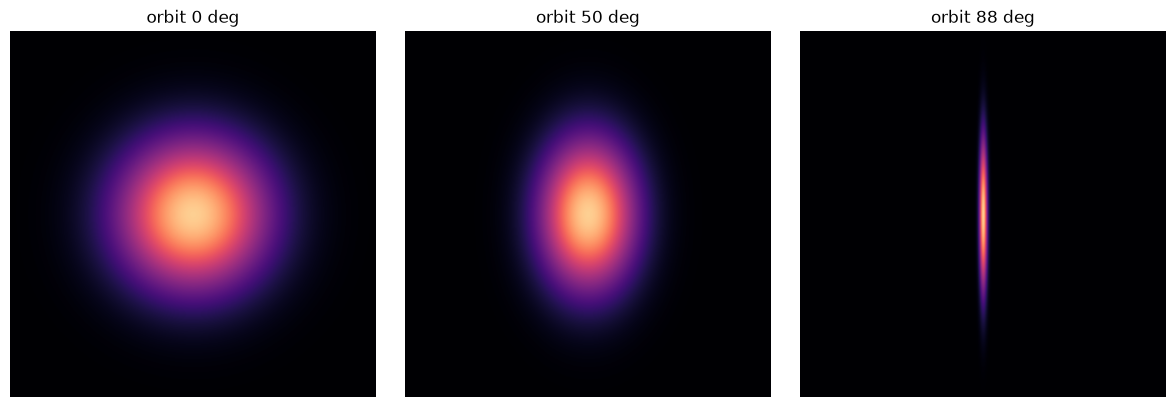

In [4]:
def render_one(cam, mean_w, cov3, o=0.9):
    mc = cam.world_to_cam(mean_w)
    u, v, _ = cam.project(mc)
    S2 = project_cov3d(cov3, mc, cam) + 0.3 * np.eye(2)
    Sinv = np.linalg.inv(S2)
    ys, xs = np.mgrid[0:cam.H, 0:cam.W]
    dx, dy = xs - u, ys - v
    power = -0.5 * (Sinv[0, 0] * dx * dx + Sinv[1, 1] * dy * dy) - Sinv[0, 1] * dx * dy
    return o * np.exp(power)

disc = build_cov3d([0.5, 0.5, 0.02], np.eye(3))
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, az_deg in zip(axes, [0, 50, 88]):
    a = np.deg2rad(az_deg)
    c = Camera.looking_at(eye=[4 * np.sin(a), 0, -4 * np.cos(a)],
                          target=[0, 0, 0], fx=600, fy=600, H=512, W=512)
    ax.imshow(render_one(c, [0, 0, 0], disc), cmap="magma", vmin=0, vmax=1)
    ax.set_title(f"orbit {az_deg} deg")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Exercise

Place an isotropic splat (scale `s = 0.1` on all axes) on the optical axis
and vary its depth. From `Sigma_2d`, compute the 3-sigma radius at each depth
and compare with notebook 01's point-with-radius formula. What should the
relationship be, and why exactly on-axis?

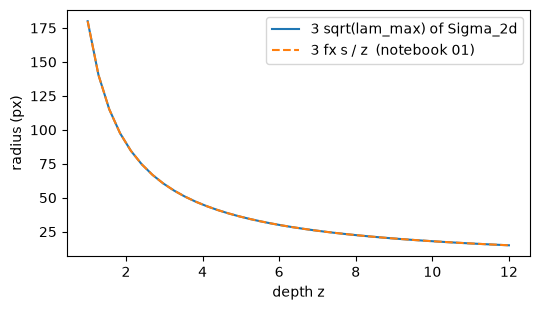

In [5]:
s = 0.1
depths = np.linspace(1.0, 12.0, 40)
radii = []
for d in depths:
    mc = np.array([0.0, 0.0, d])
    S2 = project_cov3d(build_cov3d([s, s, s], np.eye(3)), mc, cam)
    lam_max = np.linalg.eigvalsh(S2)[-1]
    radii.append(3 * np.sqrt(lam_max))

plt.figure(figsize=(5.5, 3.2))
plt.plot(depths, radii, label="3 sqrt(lam_max) of Sigma_2d")
plt.plot(depths, 3 * cam.fx * s / depths, ls="--", label="3 fx s / z  (notebook 01)")
plt.xlabel("depth z"); plt.ylabel("radius (px)")
plt.legend(); plt.tight_layout(); plt.show()

assert np.allclose(radii, 3 * cam.fx * s / depths)

## Solution

On-axis, `x = y = 0`, so `J`'s third column vanishes and
`Sigma_2d = (fx s / z)^2 I` exactly: the general machinery collapses to the
similar-triangles formula, radius proportional to `fx s / z`. Off-axis the
third column is nonzero and depth uncertainty leaks into the screen ellipse,
which is precisely what a point-with-radius model cannot express.

We can now turn any 3D Gaussian into a correct screen ellipse. A scene is
thousands of them, overlapping. Notebook 05 blends them.